# 초기 긍정률이 높을수록 흥행했는가

In [54]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'    # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [47]:
stratified_games = pd.read_csv('../../../data/processed/steam_stratified_74_games.csv')
stratified_reviews = pd.read_csv('../../../data/processed/steam_indie_reviews.csv')
histogram = pd.read_csv('../../../data/processed/steam_review_histogram.csv')

print(f"target_games: {stratified_games.shape}")
print(f"target_reviews: {stratified_reviews.shape}")
print(f"histogram: {histogram.shape}")

target_games: (74, 14)
target_reviews: (13106, 21)
histogram: (6003, 9)


In [48]:
stratified_reviews.head(5)

,recommendationid,appid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,...,steam_purchase,received_for_free,written_during_early_access,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played
0,134554560,1432860,english,"For me, Sun Haven is a fun farming game that h...",1678643330,1678643330,True,1432,25,0.971922,...,True,False,False,76561199471119493,0,1,4120,0,1723,1763967370
1,135610350,1432860,english,*Updated for v1.0.3*\n\nI really love this gam...,1680018629,1680192211,False,1564,18,0.939696,...,True,False,False,76561198107464933,663,108,12951,0,8605,1690050219
2,136483272,1432860,english,(Singleplayer review)\nPuh i am not really sur...,1681149417,1681149417,True,166,0,0.917131,...,True,False,False,76561198005466151,1021,4,3653,0,3400,1723728962
3,138973732,1432860,russian,"Я наиграла в эту игру почти 55 часов, 40+ из к...",1685034459,1685034459,False,224,7,0.897391,...,True,False,False,76561198098873026,720,16,3280,0,3280,1684534023
4,136801481,1432860,japanese,Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,1681649431,1682154116,True,143,10,0.895801,...,True,False,False,76561199151368353,0,1,12057,0,7849,1723475976


In [49]:
# 출시일로부터 3개월 데이터 존재 여부 확인
# 1. games에 cutoff_date 추가
stratified_games['release_date'] = pd.to_datetime(stratified_games['release_date'])
stratified_games['cutoff_date'] = stratified_games['release_date'] + pd.DateOffset(months=3)

# 2. reviews 날짜 변환
stratified_reviews['review_date'] = pd.to_datetime(stratified_reviews['timestamp_created'], unit='s')

# 3. 머지
df = stratified_games.merge(stratified_reviews, how="inner", on="appid")

# 4. 3개월 이내 필터링
df_3months = df[df['review_date'] <= df['cutoff_date']]

# 3개월 이내 리뷰가 있는 appid 목록
appids_with_data = df_3months['appid'].unique()

# games에서 해당 appid가 없는 것만 필터링
games_no_data = stratified_games[~stratified_games['appid'].isin(appids_with_data)]

print(f"3개월 이내 데이터 없는 게임 수: {len(games_no_data)}")
games_no_data[['appid', 'name_store', 'release_date']]

3개월 이내 데이터 없는 게임 수: 1


,appid,name_store,release_date
24,2334220,Home Sweet Home : Online,2023-06-21


In [50]:
# 1. reviews에 아예 없는 appid (inner join에서 탈락한 것)
appids_in_reviews = stratified_reviews['appid'].unique()
games_not_in_reviews = stratified_games[~stratified_games['appid'].isin(appids_in_reviews)]
print(f"리뷰 데이터 자체가 없는 게임: {len(games_not_in_reviews)}개")

# 2. 리뷰는 있지만 3개월 이후에만 있는 경우
appids_in_merge = df['appid'].unique()
appids_with_3m = df_3months['appid'].unique()
games_late_reviews = stratified_games[
    stratified_games['appid'].isin(appids_in_merge) & ~stratified_games['appid'].isin(appids_with_3m)
]
print(f"리뷰는 있지만 3개월 이후만 있는 게임: {len(games_late_reviews)}개")


리뷰 데이터 자체가 없는 게임: 1개
리뷰는 있지만 3개월 이후만 있는 게임: 0개


In [51]:
# 긍정률
# df_3months의 voted_up 컬럼으로 3개월 이내 긍정률 계산
early_stats = df_3months.groupby('appid').agg(
    early_positive=('voted_up', 'sum'),      # True == 1
    early_total=('voted_up', 'count')
).reset_index()

early_stats['positive_rate_3m'] = early_stats['early_positive'] / early_stats['early_total'] * 100
df.shape

(13106, 36)

In [57]:
# 흥행 지표 구성
# 1. histogram에서 출시 3개월 이내 리뷰 수 집계
histogram['date'] = pd.to_datetime(histogram['date'], unit='s')
histogram['release_date'] = pd.to_datetime(histogram['release_date'])
histogram['cutoff_date'] = histogram['release_date'] + pd.DateOffset(months=3)

histogram_3m = histogram[histogram['date'] <= histogram['cutoff_date']]

early_review_count = histogram_3m.groupby('appid').agg(
    early_review_count=('recommendations_up', 'sum'),
).reset_index()
early_review_count['early_review_count'] = (
    histogram_3m.groupby('appid')['recommendations_up'].sum()
    + histogram_3m.groupby('appid')['recommendations_down'].sum()
).values

# 2. 흥행 지표 머지: owners_lower + early_review_count + 초기 긍정률
result = stratified_games[['appid', 'name_store', 'owners_lower']].merge(
    early_review_count, how='left', on='appid'
).merge(
    early_stats[['appid', 'positive_rate_3m']], how='left', on='appid'
)

result.to_csv('../../../data/processed/stratified_games_early_reviews.csv', index=False)

print(result.shape)
result.head(10)

(74, 5)


,appid,name_store,owners_lower,early_review_count,positive_rate_3m
0,1432860,Sun Haven,500000,8174,72.000000
1,1473350,(the) Gnorp Apologue,200000,3999,92.000000
2,1993150,轮回修仙路,200000,1994,69.000000
3,2527500,MiSide,1000000,91831,100.000000
4,1169040,Necesse,1000000,23053,79.000000
5,3244220,A Game About Digging A Hole™,500000,13023,93.939394
6,1948800,Yi Xian: The Cultivation Card Game,500000,4865,69.000000
7,1607680,Bread & Fred,200000,1101,89.000000
8,1956800,Thriving City: Song,200000,2396,69.000000
9,2186320,Ages of Conflict: World War Simulator,200000,657,95.959596


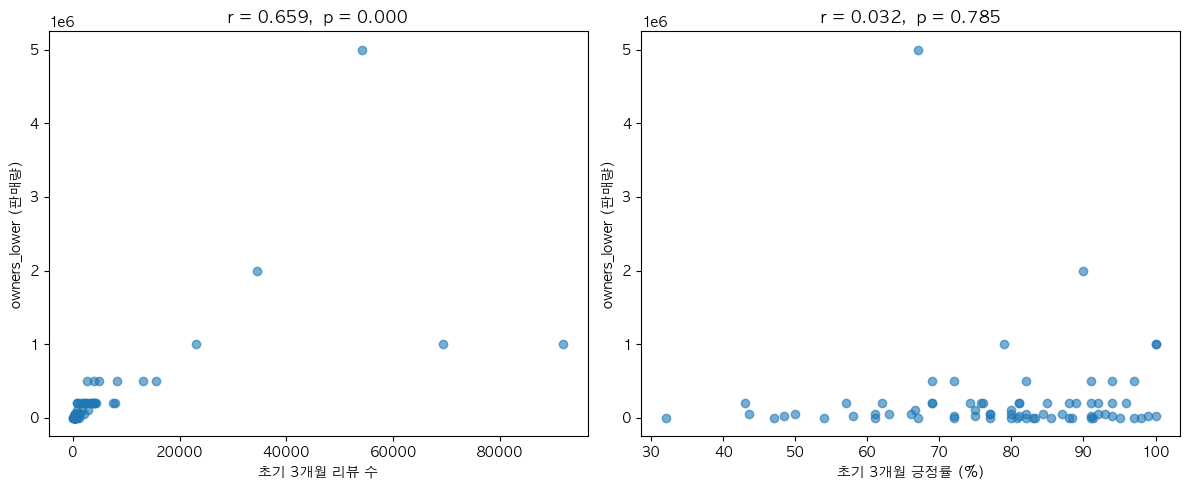

early_review_count vs owners_lower : r=0.659, p=0.000
positive_rate_3m   vs owners_lower : r=0.032, p=0.785


In [55]:
# owners_lower 기준으로 각 지표와의 상관관계 검증
analysis = result.dropna(subset=['owners_lower', 'early_review_count', 'positive_rate_3m'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(
    axes,
    ['early_review_count', 'positive_rate_3m'],
    ['초기 3개월 리뷰 수', '초기 3개월 긍정률 (%)']
):
    ax.scatter(analysis[col], analysis['owners_lower'], alpha=0.6)
    r, p = stats.pearsonr(analysis[col], analysis['owners_lower'])
    ax.set_xlabel(label)
    ax.set_ylabel('owners_lower (판매량)')
    ax.set_title(f'r = {r:.3f},  p = {p:.3f}')

plt.tight_layout()
plt.show()

r1, p1 = stats.pearsonr(analysis['early_review_count'], analysis['owners_lower'])
r2, p2 = stats.pearsonr(analysis['positive_rate_3m'],   analysis['owners_lower'])
print(f"early_review_count vs owners_lower : r={r1:.3f}, p={p1:.3f}")
print(f"positive_rate_3m   vs owners_lower : r={r2:.3f}, p={p2:.3f}")

In [56]:
print(analysis['positive_rate_3m'].describe())

count     73.000000
mean      78.266410
std       15.518362
min       32.000000
25%       69.000000
50%       81.000000
75%       91.000000
max      100.000000
Name: positive_rate_3m, dtype: float64


In [ ]:
# early_review_count와 positive_rate_3m 간의 관계 분석
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(analysis['positive_rate_3m'], analysis['early_review_count'], alpha=0.6)

r, p = stats.pearsonr(analysis['positive_rate_3m'], analysis['early_review_count'])
ax.set_xlabel('초기 3개월 긍정률 (%)')
ax.set_ylabel('초기 3개월 리뷰 수')
ax.set_title(f'초기 긍정률 vs 초기 리뷰 수\nr = {r:.3f},  p = {p:.3f}')

plt.tight_layout()
plt.show()

print(f"positive_rate_3m vs early_review_count : r={r:.3f}, p={p:.3f}")